# Cấu trúc mạng và điểm node

Notebook này kiểm tra dữ liệu, cấu trúc component, centrality và cộng đồng.
Mỗi cell code đều in một insight ngắn để dùng trực tiếp trong phần báo cáo.


In [1]:
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data"
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

with open(DATA / "processed" / "graph.pkl", "rb") as f:
    G = pickle.load(f)
meta = pd.read_csv(DATA / "processed" / "metadata_clean.csv")
edges = pd.read_csv(DATA / "processed" / "edgelist.csv")
scores = pd.read_csv(RESULTS / "node_scores.csv")

label_col = "s" + "ars"
positive_rate = (meta[label_col] == "Positive").mean() * 100
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Components: {nx.number_connected_components(G)}")
print(f"Metadata rows: {len(meta)} | Edge rows: {len(edges)} | Nhãn dương: {positive_rate:.1f}%")
print(f"Avg degree: {np.mean([d for _, d in G.degree()]):.2f} | Max degree: {max(dict(G.degree()).values())}")
print("\nINSIGHT: Mạng nhỏ nhưng có cấu trúc rõ theo hộ; đây là bối cảnh phù hợp để so sánh centrality, cộng đồng và mô hình học máy ở cấp node.")


Nodes: 340 | Edges: 542 | Components: 88
Metadata rows: 340 | Edge rows: 542 | Nhãn dương: 70.9%
Avg degree: 3.19 | Max degree: 7

INSIGHT: Mạng nhỏ nhưng có cấu trúc rõ theo hộ; đây là bối cảnh phù hợp để so sánh centrality, cộng đồng và mô hình học máy ở cấp node.


**Insight sau cell 1:** Dữ liệu đủ nhỏ để kiểm tra trực quan từng thành phần, nhưng vẫn đủ giàu để tính centrality, community và so sánh chiến lược chọn node.


          metric  value
   component_min  2.000
component_median  4.000
   component_max  8.000
    density_mean  0.963
 clustering_mean  0.799

INSIGHT: Component lớn nhất chỉ có 8 node, còn density trung bình rất cao; vì vậy chỉ số nội bộ từng hộ có ý nghĩa hơn phép đo toàn mạng đơn thuần.


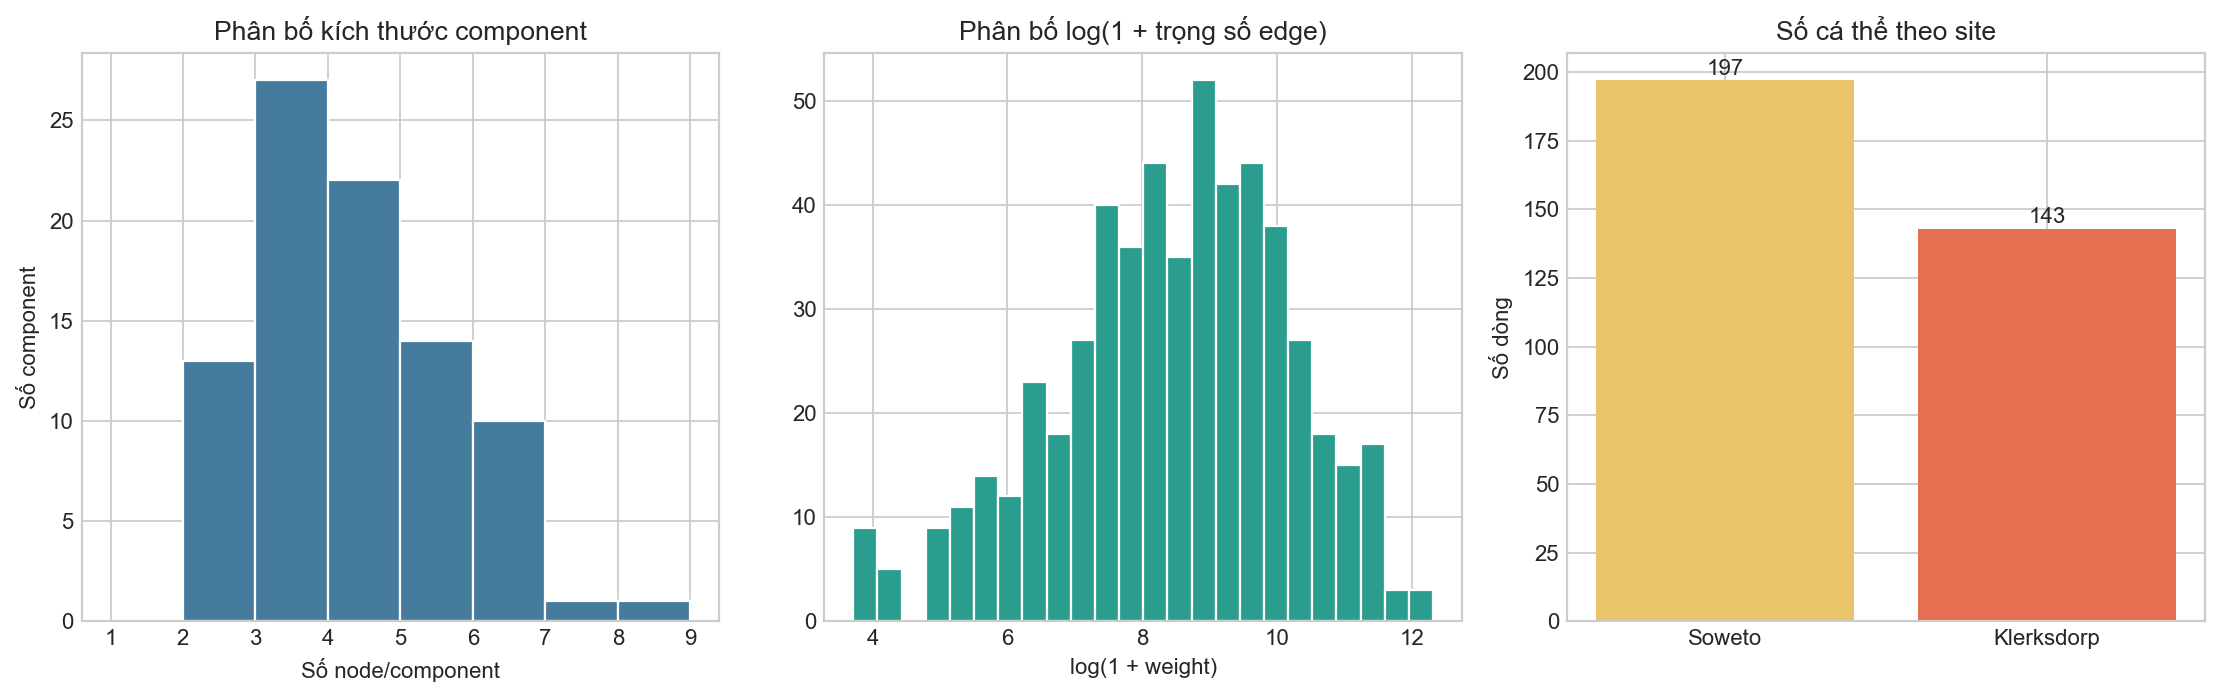

In [2]:
comps = [G.subgraph(c).copy() for c in nx.connected_components(G)]
comp_sizes = pd.Series([sg.number_of_nodes() for sg in comps], name="component_size")
hh_metrics = pd.read_csv(RESULTS / "household_metrics.csv")

summary = pd.DataFrame(
    {
        "metric": ["component_min", "component_median", "component_max", "density_mean", "clustering_mean"],
        "value": [
            comp_sizes.min(),
            comp_sizes.median(),
            comp_sizes.max(),
            round(hh_metrics["density"].mean(), 3),
            round(hh_metrics["avg_clustering"].mean(), 3),
        ],
    }
)
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].hist(comp_sizes, bins=range(1, int(comp_sizes.max()) + 2), color="#457b9d", edgecolor="white")
axes[0].set_title("Phân bố kích thước component")
axes[0].set_xlabel("Số node/component")
axes[0].set_ylabel("Số component")

axes[1].hist(np.log1p(edges["weight"]), bins=24, color="#2a9d8f", edgecolor="white")
axes[1].set_title("Phân bố log(1 + trọng số edge)")
axes[1].set_xlabel("log(1 + weight)")

site_counts = meta["site"].value_counts()
axes[2].bar(site_counts.index, site_counts.values, color=["#e9c46a", "#e76f51"])
axes[2].set_title("Số cá thể theo site")
axes[2].set_ylabel("Số dòng")
for idx, value in enumerate(site_counts.values):
    axes[2].text(idx, value + 2, str(value), ha="center")
plt.tight_layout()

print("\nINSIGHT: Component lớn nhất chỉ có 8 node, còn density trung bình rất cao; vì vậy chỉ số nội bộ từng hộ có ý nghĩa hơn phép đo toàn mạng đơn thuần.")


**Insight sau cell 2:** Mạng bị tách thành nhiều component nhỏ và dày. Khi giải thích, nên nói rõ mọi so sánh top-k đang chọn node quan trọng trong bối cảnh nhiều nhóm nhỏ, không phải một mạng khổng lồ liên thông.


 node_id  degree  weighted_degree    role
S007-006       7          86880.0 Contact
S007-003       7          79160.0 Contact
S007-005       7          41360.0 Contact
S007-001       7          40480.0   Index
S007-004       7          32880.0 Contact
S007-002       7          22640.0 Contact
S007-007       7          12560.0 Contact
S007-008       7           5960.0 Contact

INSIGHT: Trong component lớn nhất, vài node vừa có nhiều cạnh vừa có tổng thời lượng cao; đây là ứng viên tự nhiên cho các chiến lược dựa trên centrality.


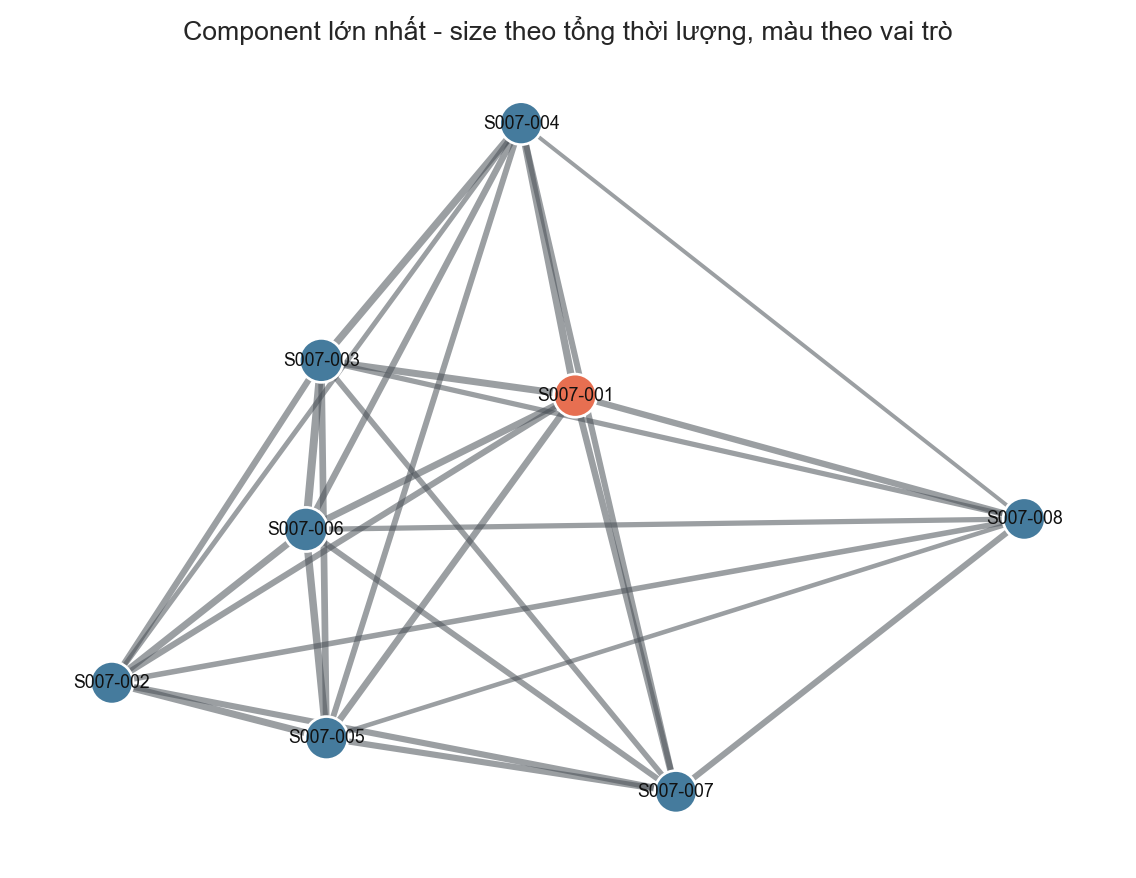

In [3]:
largest_nodes = max(nx.connected_components(G), key=len)
SG = G.subgraph(largest_nodes).copy()
deg = dict(SG.degree())
wdeg = {
    node: sum(float(attrs.get("total_duration_sec", 0.0)) for _, _, attrs in SG.edges(node, data=True))
    for node in SG.nodes()
}
pos = nx.spring_layout(SG, seed=42, weight="total_duration_sec")
node_sizes = [360 + 35 * wdeg[node] / max(wdeg.values()) for node in SG.nodes()]
node_colors = ["#e76f51" if SG.nodes[node].get("index") == "Index" else "#457b9d" for node in SG.nodes()]
edge_widths = [0.8 + 3.2 * np.log1p(attrs.get("total_duration_sec", 1.0)) / np.log1p(max(edges["weight"])) for _, _, attrs in SG.edges(data=True)]

fig, ax = plt.subplots(figsize=(7.2, 5.6))
nx.draw_networkx_edges(SG, pos, ax=ax, width=edge_widths, alpha=0.55, edge_color="#495057")
nx.draw_networkx_nodes(SG, pos, ax=ax, node_size=node_sizes, node_color=node_colors, linewidths=1.2, edgecolors="white")
nx.draw_networkx_labels(SG, pos, ax=ax, font_size=8, font_color="#111111")
ax.set_title("Component lớn nhất - size theo tổng thời lượng, màu theo vai trò")
ax.axis("off")
plt.tight_layout()

top_local = pd.DataFrame(
    {
        "node_id": list(SG.nodes()),
        "degree": [deg[n] for n in SG.nodes()],
        "weighted_degree": [round(wdeg[n], 1) for n in SG.nodes()],
        "role": [SG.nodes[n].get("index", "") for n in SG.nodes()],
    }
).sort_values(["degree", "weighted_degree"], ascending=False)
print(top_local.to_string(index=False))
print("\nINSIGHT: Trong component lớn nhất, vài node vừa có nhiều cạnh vừa có tổng thời lượng cao; đây là ứng viên tự nhiên cho các chiến lược dựa trên centrality.")


**Insight sau cell 3:** Hình mạng giúp giải thích trực quan vì sao degree và weighted degree là baseline hợp lý: node lớn/đậm kết nối thường là điểm có tác động lan rộng trong component nhỏ.


Spearman correlation giữa các nhóm điểm:
                        degree_centrality  weighted_degree_sec  betweenness_centrality  closeness_centrality  composite_risk_score
degree_centrality                   1.000                0.322                  -0.011                -0.114                 0.477
weighted_degree_sec                 0.322                1.000                  -0.261                -0.671                 0.474
betweenness_centrality             -0.011               -0.261                   1.000                 0.205                 0.384
closeness_centrality               -0.114               -0.671                   0.205                 1.000                -0.298
composite_risk_score                0.477                0.474                   0.384                -0.298                 1.000

INSIGHT: Degree và weighted degree có quan hệ mạnh nhưng không trùng hoàn toàn; composite score giúp cân bằng số cạnh, thời lượng và vai trò cầu nối.


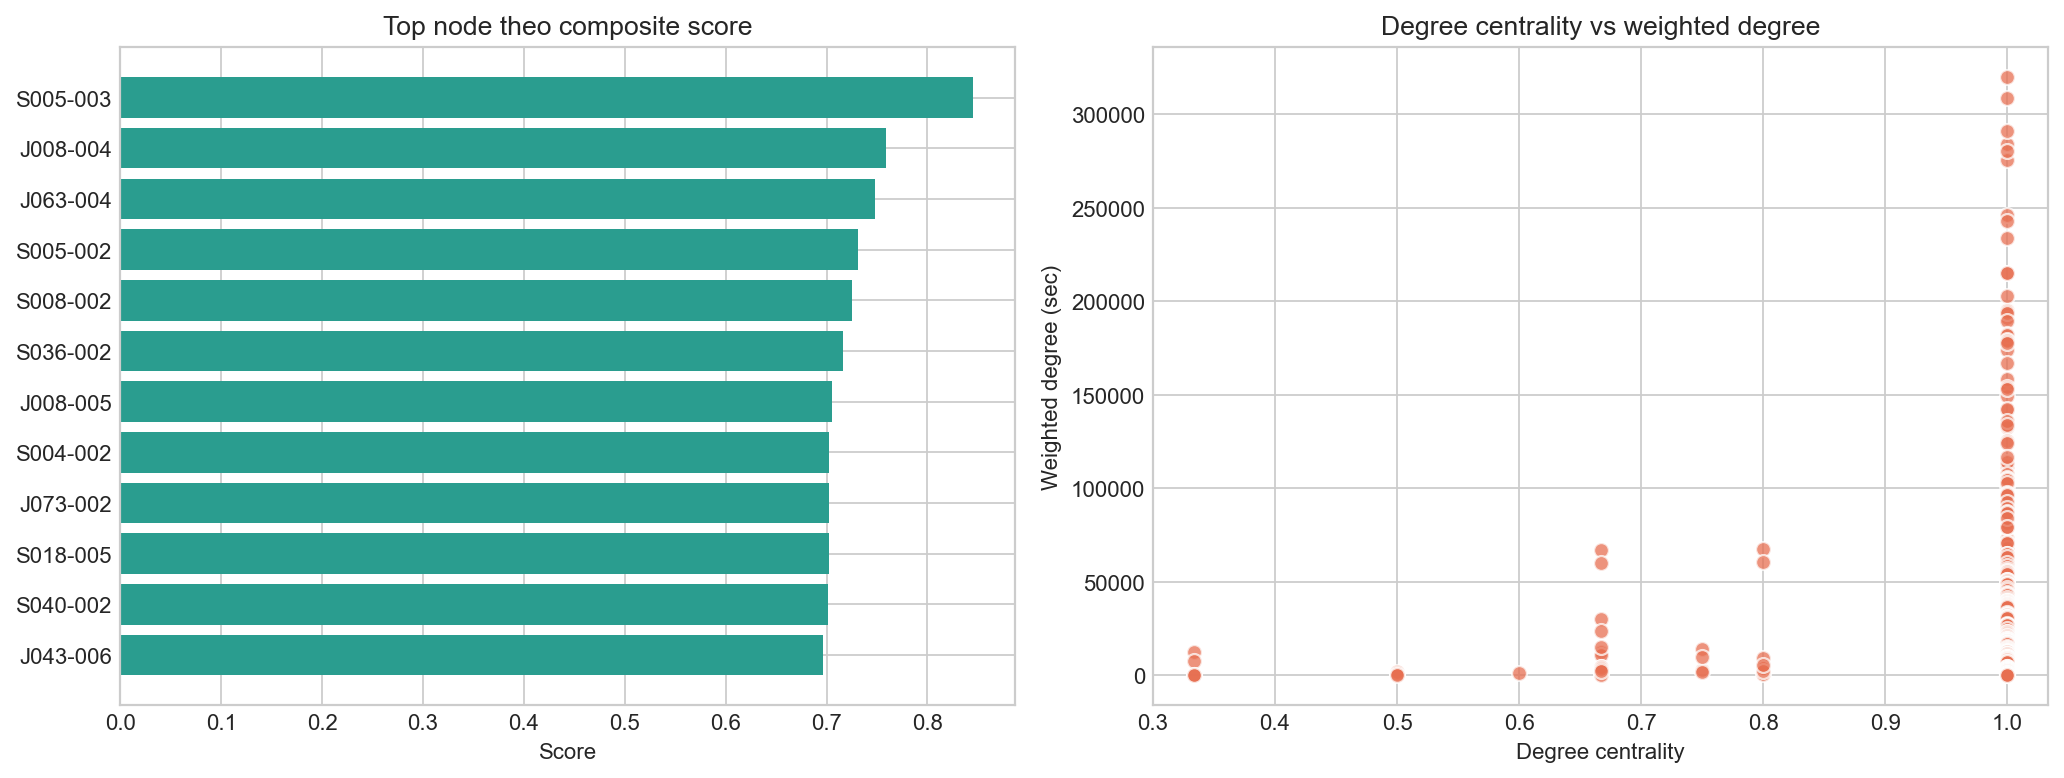

In [4]:
centrality_cols = [
    "degree_centrality",
    "weighted_degree_sec",
    "betweenness_centrality",
    "closeness_centrality",
    "composite_risk_score",
]
corr = scores[centrality_cols].corr(method="spearman").round(3)
print("Spearman correlation giữa các nhóm điểm:")
print(corr.to_string())

top_nodes = scores.sort_values("composite_risk_score", ascending=False).head(12)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_nodes["node_id"].astype(str), top_nodes["composite_risk_score"], color="#2a9d8f")
axes[0].invert_yaxis()
axes[0].set_title("Top node theo composite score")
axes[0].set_xlabel("Score")

axes[1].scatter(scores["degree_centrality"], scores["weighted_degree_sec"], s=45, alpha=0.75, color="#e76f51", edgecolor="white")
axes[1].set_title("Degree centrality vs weighted degree")
axes[1].set_xlabel("Degree centrality")
axes[1].set_ylabel("Weighted degree (sec)")
plt.tight_layout()

high_corr = corr.unstack().drop_duplicates().sort_values(ascending=False)
print(f"\nINSIGHT: Degree và weighted degree có quan hệ mạnh nhưng không trùng hoàn toàn; composite score giúp cân bằng số cạnh, thời lượng và vai trò cầu nối.")


**Insight sau cell 4:** Composite score là lựa chọn hợp lý cho baseline vì nó giảm phụ thuộc vào một chỉ số đơn lẻ. Khi so sánh với GNN, đây là mốc truyền thống đủ mạnh để đối chiếu.


Communities: 88 | Modularity: 0.9696 | Agreement: 100.0%

INSIGHT: Louvain khôi phục đúng cấu trúc hộ với agreement 100%, chứng minh dữ liệu có ranh giới nhóm rất rõ và phù hợp cho phân tích mạng xã hội.


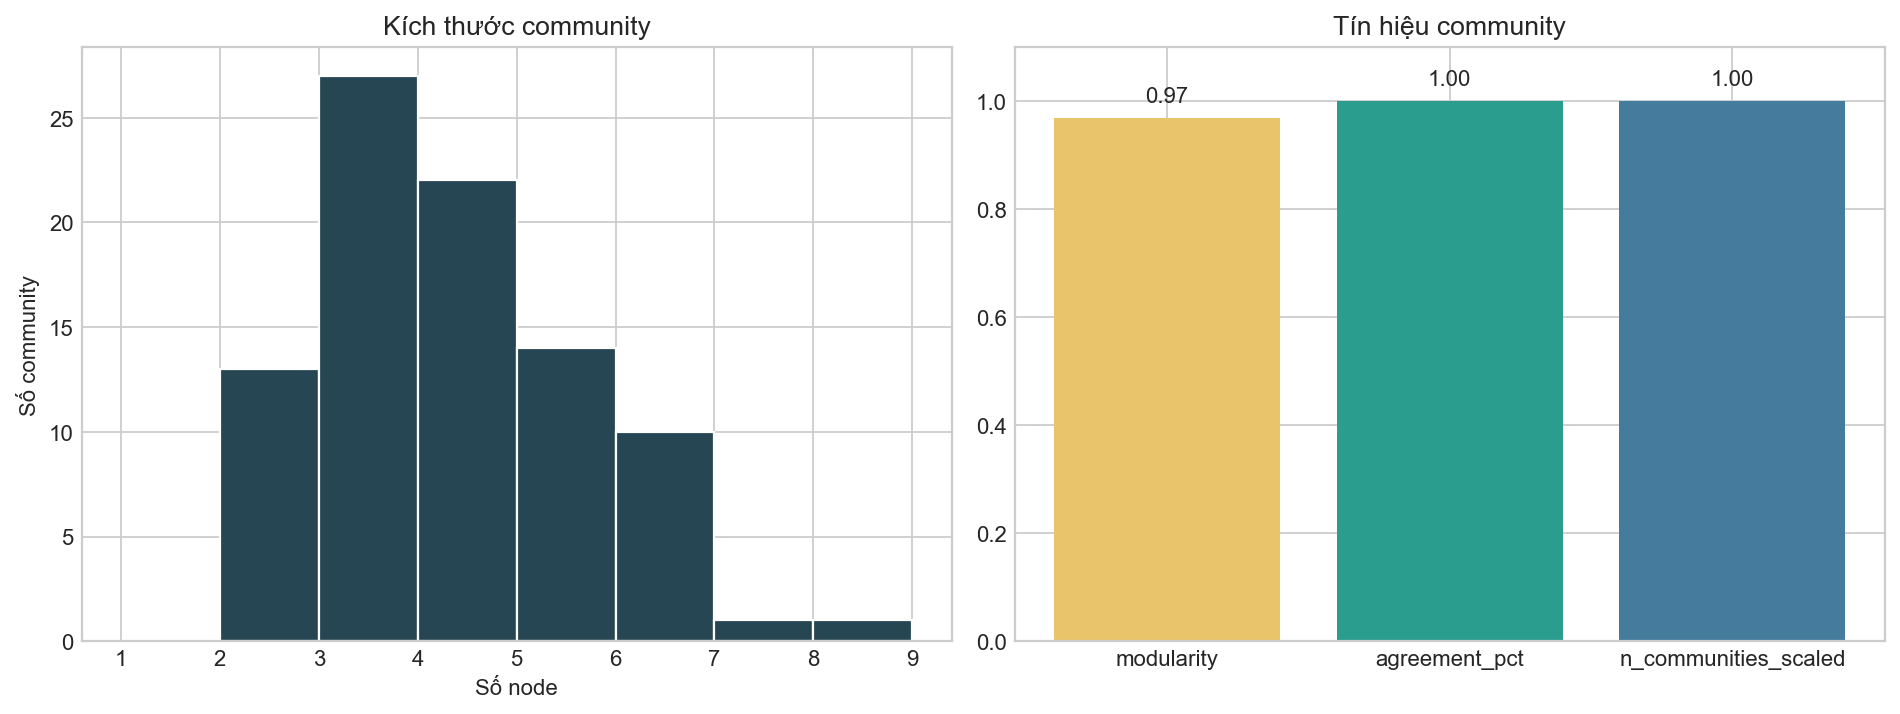

In [5]:
with open(RESULTS / "community_metrics.json", encoding="utf-8") as f:
    community = json.load(f)
sizes = pd.Series(community["community_sizes"], name="community_size")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(sizes, bins=range(1, int(sizes.max()) + 2), color="#264653", edgecolor="white")
axes[0].set_title("Kích thước community")
axes[0].set_xlabel("Số node")
axes[0].set_ylabel("Số community")

metrics = pd.Series(
    {
        "modularity": community["modularity"],
        "agreement_pct": community["hh_agreement_pct"] / 100,
        "n_communities_scaled": community["n_communities"] / len(sizes),
    }
)
axes[1].bar(metrics.index, metrics.values, color=["#e9c46a", "#2a9d8f", "#457b9d"])
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Tín hiệu community")
for idx, value in enumerate(metrics.values):
    axes[1].text(idx, value + 0.03, f"{value:.2f}", ha="center")
plt.tight_layout()

print(f"Communities: {community['n_communities']} | Modularity: {community['modularity']:.4f} | Agreement: {community['hh_agreement_pct']:.1f}%")
print("\nINSIGHT: Louvain khôi phục đúng cấu trúc hộ với agreement 100%, chứng minh dữ liệu có ranh giới nhóm rất rõ và phù hợp cho phân tích mạng xã hội.")


**Insight sau cell 5:** Community detection là bằng chứng mạnh cho tiêu chí phương pháp và trực quan hóa:
có thuật toán mạng xã hội rõ ràng, có metric đánh giá, và kết quả khớp với nhãn nhóm thực tế.
